# AG-HYPOPT · Trial 02

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

One trial is recorded. trial_01 (sigma_weight=0.409, h_f_scale=1.837, h_s_scale=3.354, gamma_rel_cap=0.156) is the current best (and only) trial: objective 0.1243 +/- 0.081, 0 diverged cells, gamma finite on all 8 cells, mu rel-RMSE 58.1% (mixed sign - overshoot at low T, undershoot at high T) and gamma rel-RMSE 27.3% (under-estimated at low T, recovered at high T). It sits above the experiment_5 honest level (~0.108-0.113). The campaign is still in the uniform phase (1/5 completed), so the candidates below are independent random draws.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_02'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (1/5 trials)
ID |     ei | params
 1 |      - | {"gamma_rel_cap": 0.1308060671246582, "h_f_scale": 1.3693417878029623, "h_s_scale": 3.3033465272285514, "sigma_weight": 0.0919159421350969}
 2 |      - | {"gamma_rel_cap": 0.300050262982827, "h_f_scale": 2.98210197554423, "h_s_scale": 0.9546290251247629, "sigma_weight": 0.05514662733306819}
 3 |      - | {"gamma_rel_cap": 0.13748468395301905, "h_f_scale": 2.715373805783472, "h_s_scale": 2.358496235426605, "sigma_weight": 0.15006226330533612}
 4 |      - | {"gamma_rel_cap": 0.21631539540239358, "h_f_scale": 2.759864869654451, "h_s_scale": 1.8354425247629793, "sigma_weight": 0.6331843992741164}
 5 |      - | {"gamma_rel_cap": 0.4837179762468383, "h_f_scale": 2.811493083661095, "h_s_scale": 1.718593124050098, "sigma_weight": 0.18725256972009807}
 6 |      - | {"gamma_rel_cap": 0.17298033278586655, "h_f_scale": 2.166497400885914, "h_s_scale": 3.592035285627172, "sigma_weight": 0.7755639424726894}
 7 |      - | {"gamma_rel_cap

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Registry so far: a single trial, trial_01 (sw 0.409, h_s 3.354, h_f 1.837, cap 0.156) at objective 0.1243, no divergences but mu-dominated error (rel-RMSE 58.1%). We are still in the uniform phase (1/5), so all ten candidates are independent random draws with ei = '-'; the choice is based on trial_01 and the candidate values.

trial_01 strongly damped the sigma channel (low sw with a very flat h_s) and landed above the experiment_5 honest level (~0.108-0.113), whose frozen design is sw~1, h_s~1, cap~0. The most informative next draw is therefore the candidate nearest those defaults, to re-establish the reference level under this harness before moving away from it: candidate 8 (sw 0.884, h_s 1.007, h_f 0.642, cap 0.054). It keeps the sigma link nearly full strength, mildly sharpens the FWHM kernel (h_f 0.64, testing FM#4 bandwidth inflation in the opposite direction) and applies only a small gamma cap, so the gamma channel is barely touched.

I choose candidate 8.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8               # candidate 8: sigma_weight 0.884, h_s_scale 1.007, h_f_scale 0.642, gamma_rel_cap 0.054 (near exp5 reference)


chosen: {'gamma_rel_cap': 0.05360365422679403, 'h_f_scale': 0.6420383441235307, 'h_s_scale': 1.0071529282354388, 'sigma_weight': 0.8844496736882935}
Running  1nW Trans05 ... 

μ 9.39 -> 14.32 | γ 8.5 -> 6.74 | NLL 1.42


Running  1nW Trans20 ... 

μ 17.32 -> 47.95 | γ 8.5 -> 6.29 | NLL 7.37


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 77.84 | γ 14.1 -> 14.25 | NLL 4.74


Running 3nW Trans100 ... 

μ 175.71 -> 108.89 | γ 14.1 -> 13.91 | NLL 3.84



Total: 7.2 min


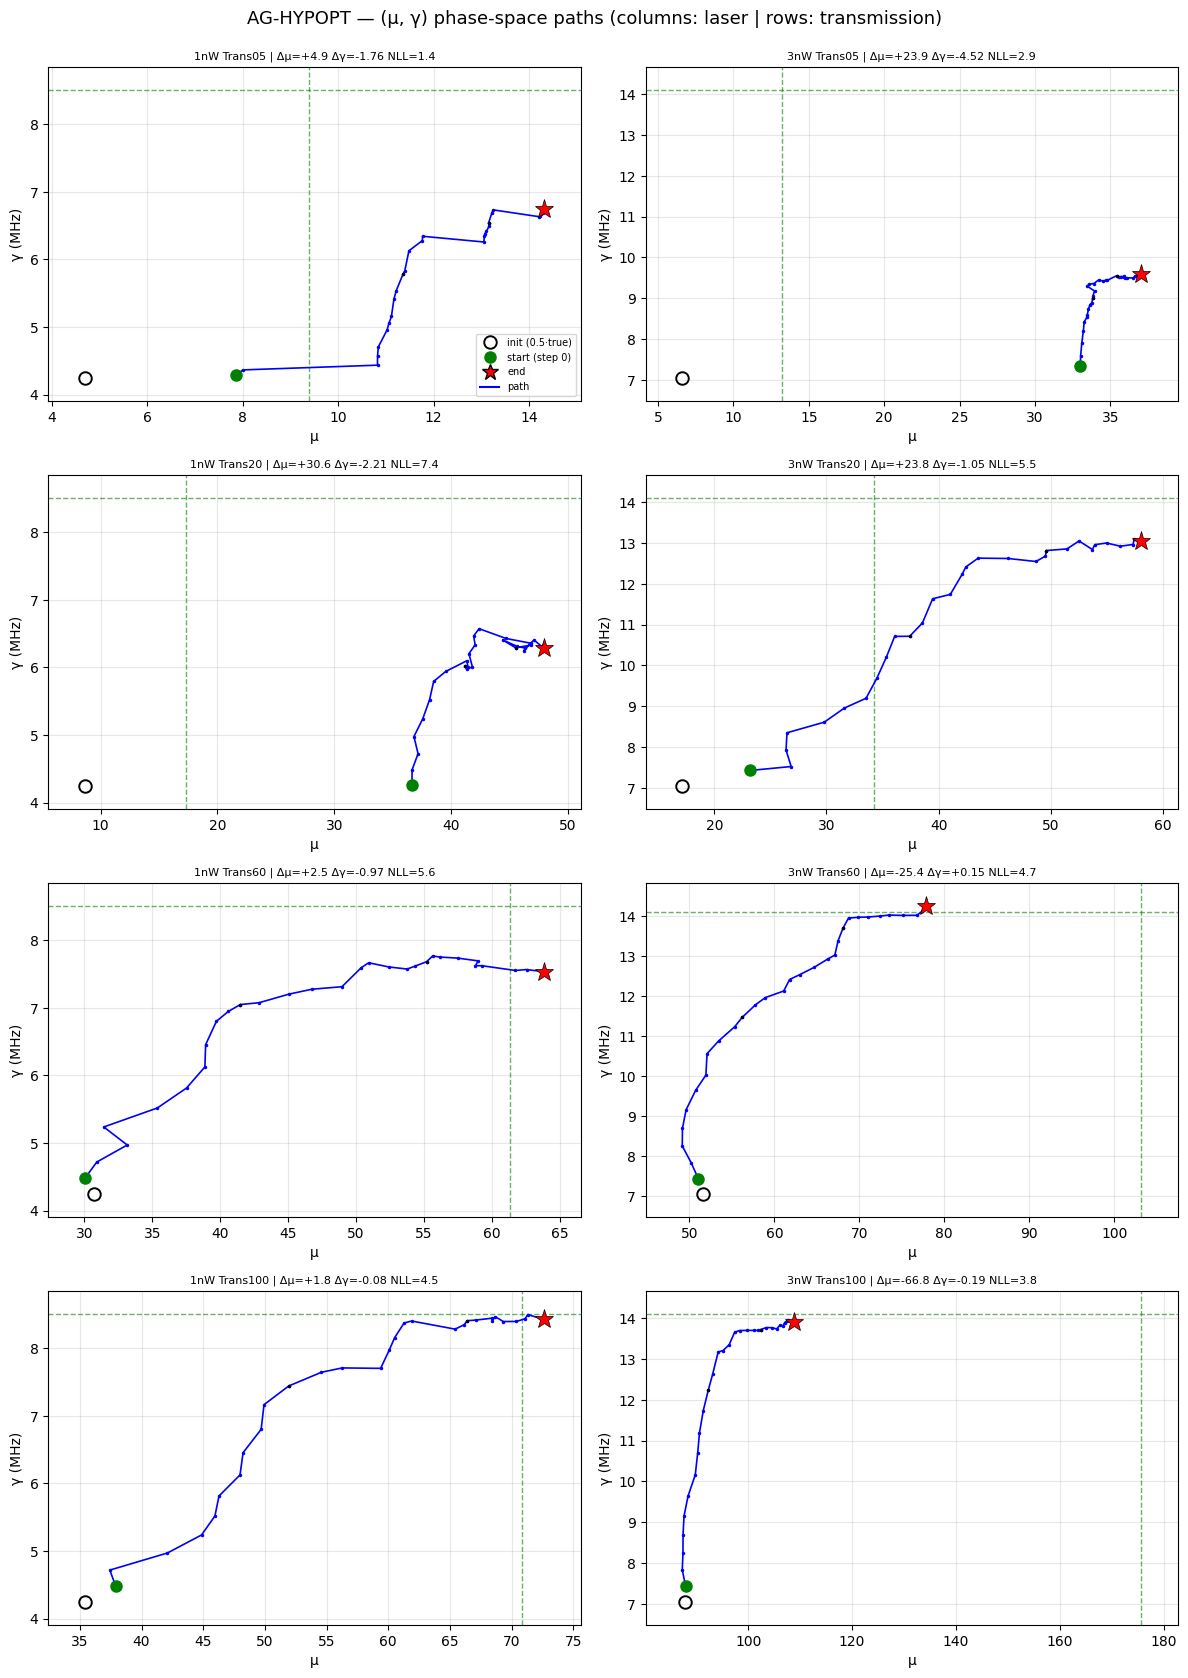

trial finished in 7.2 min
objective = 0.1287 ± 0.0844
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   14.32   +52.4 |     8.50    6.74   -20.7
1nW Trans20       17.32   47.95  +176.9 |     8.50    6.29   -26.0
1nW Trans60       61.37   63.86    +4.1 |     8.50    7.53   -11.4
1nW Trans100       70.82   72.64    +2.6 |     8.50    8.42    -0.9
3nW Trans05       13.20   37.07  +180.8 |    14.10    9.58   -32.0
3nW Trans20       34.28   58.09   +69.5 |    14.10   13.05    -7.4
3nW Trans60      103.20   77.84   -24.6 |    14.10   14.25    +1.1
3nW Trans100      175.71  108.89   -38.0 |    14.10   13.91    -1.4

weighted objective (T-graded, cap=1.0) = 0.1287 | diverged cells: 0
μ: RMSE 30.034 (rel 95.9%, bias -0.579) | γ: RMSE 1.952 (rel 17.0%, bias -1.327)


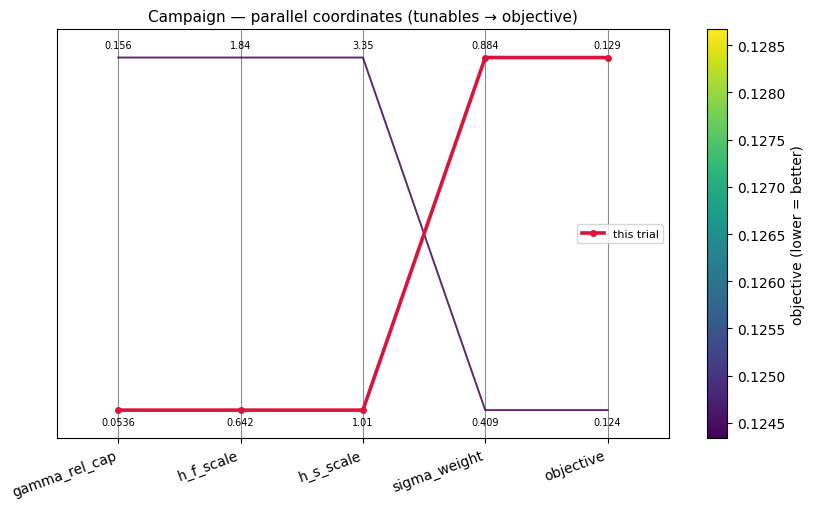

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 02 (sw 0.884, h_f 0.642, h_s 1.007, cap 0.054) ran to completion in 7.2 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.1287 +/- 0.0844, above trial_01 (0.1243) and the experiment_5 honest level (~0.108-0.113).

mu was much worse than trial_01: rel-RMSE 95.9% vs 58.1%, driven by a large positive overshoot at low T (1nW Trans20 +176.9%, 3nW Trans05 +180.8%, 3nW Trans20 +69.5%, 1nW Trans05 +52.4%), while the highest-mu cells undershoot (3nW Trans100 -38.0%, 3nW Trans60 -24.6%). Overall bias is small (-0.58) because overshoots and undershoots cancel, but the scatter is large.

gamma was better than trial_01: rel-RMSE 17.0% vs 27.3%; under-estimated at low T (-32.0%, -26.0%, -20.7%, -7.4%) and recovered at high T (-0.9%, +1.1%, -1.4%).

The chosen candidate moved back toward the frozen exp5 design (near-full sigma weight, near-nominal sigma kernel) but sharpened the FWHM kernel (h_f 0.64); relative to trial_01 this raised both the objective and the mu error while lowering the gamma error.

**Summary:** Trial 02 (sw=0.884, h_f=0.642, h_s=1.007, cap=0.054) finished in 7.2 min with 0 diverged cells and gamma finite, objective 0.1287 +/- 0.0844 (above trial_01's 0.1243 and the exp5 honest level); gamma rel-RMSE improved to 17.0% but mu blew up at low T (rel-RMSE 95.9%).
**Key insight:** Near-exp5 sigma settings with a sharpened FWHM kernel (h_f 0.64) worsen the low-T mu overshoot (mu rel-RMSE 95.9%) while improving gamma (17.0%), so low-T mu accuracy is the binding problem, not sigma-channel damping alone.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 02 (sw=0.884, h_f=0.642, h_s=1.007, cap=0.054): objective 0.1287 +/- 0.0844, 0 diverged cells, gamma finite; gamma rel-RMSE 17.0% but mu blew up at low T (rel-RMSE 95.9%), worse than trial_01.'
KEY_INSIGHT = 'Near-exp5 sigma settings with a sharpened FWHM kernel (h_f 0.64) worsen the low-T mu overshoot (mu rel-RMSE 95.9%) while improving gamma (17.0%); low-T mu accuracy, not sigma damping alone, is the binding problem.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_02 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_03.ipynb. Open it and follow its cells from the top.
